In [18]:
import pytato as yt
import pandas as pd
import numpy as np
import logomaker
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [19]:
proteome_df = yt.Silico().import_fasta(source="https://ftp.uniprot.org/pub/databases/uniprot/current_release/knowledgebase/reference_proteomes/Eukaryota/UP000005640/UP000005640_9606.fasta.gz")

FASTA import complete!


# Trypsin Standard

In [20]:
results = []
silico = yt.Silico()  

for index, row in proteome_df.head(5).iterrows():
    peptides = silico.cleave_sequence(sequence=row['Peptide'], enzyme="trypsin")
    for peptide in peptides:
        results.append({
            'Gene': row['Gene'],
            'Peptide': peptide
        })

peptides_df = pd.DataFrame(results)


In [21]:
peptides_df

,Gene,Peptide
0,A0A0A0MTA3,XITFGQGTR
1,TCAF2,MATIAAAAFEALMDGVTCWDVPR
2,TCAF2,GPIPSELLLIGEAAFPVMVNDK
3,TCAF2,GQVLIAASSYGR
4,TCAF2,LVVVSHEGYLSHTGLAPFLLNAVSWLCPCPGAPVGVHPSLAPLVNI...
...,...,...
143,YF016,AAGHRPR
144,YF016,LSGPPLQLQQTPPLQLR
145,YF016,DEGPPPAK
146,YF016,LPCLSPEALLVGK


In [22]:
peptide_counts = peptides_df.groupby('Gene').size()
print(peptide_counts)


Gene
A0A0A0MTA3     1
RTL1          72
SPDL3         17
TCAF2         40
YF016         18
dtype: int64


In [23]:

specific_proteins = proteome_df[proteome_df['Gene'].isin(['PDK1',"UBE3B"])]


In [24]:
silico.missed = 1


In [25]:
peptide_properties_dic = silico.generate_samples(specific_proteins,enzyme="trypsin", target="Peptide", identifier="Gene", pH=7.4, min_charge=1.5)
peptides_df = pd.DataFrame(peptide_properties_dic)


Processing your order with trypsin-cut proteins.
Generated 42 peptides matching criteria.


In [26]:
peptides_df = peptides_df.sort_values(by='Mass', ascending=False)
peptides_df

,gene,peptide,Length,aa_comp,neutral_z,z,Mass,GRAVY,m/z
21,UBE3B,GLARPRPCLSKGTLTAAFSLALRPVIAAQFSDNLIRPFLIHIMSVP...,59,"{'N': 1, 'V': 4, 'T': 5, 'F': 3, 'L': 9, 'M': ...",4,4,6344.528628,0.503390,1586.132157
19,UBE3B,GESLRPAMNHICANIMGHLNQHGFYSVLQILLTRGLARPRPCLSK,45,"{'V': 1, 'T': 1, 'F': 1, 'C': 2, 'L': 7, 'Y': ...",4,4,4994.588069,-0.044444,1248.647017
18,UBE3B,GKGESLRPAMNHICANIMGHLNQHGFYSVLQILLTR,36,"{'V': 1, 'T': 1, 'F': 1, 'C': 1, 'L': 5, 'Y': ...",2,2,4001.033864,-0.025000,2000.516932
37,UBE3B,AMFLKFVTSCSRPPLLGFAYLKPPFSIR,28,"{'V': 1, 'T': 1, 'F': 4, 'R': 2, 'L': 4, 'Y': ...",4,4,3167.718039,0.539286,791.929510
38,UBE3B,FVTSCSRPPLLGFAYLKPPFSIR,23,"{'T': 1, 'F': 3, 'L': 3, 'A': 1, 'Y': 1, 'G': ...",3,3,2577.392999,0.378261,859.131000
35,UBE3B,NQTAALISGFRSIIKPEWIR,20,"{'T': 1, 'F': 1, 'L': 1, 'G': 1, 'Q': 1, 'S': ...",2,2,2281.269521,-0.020000,1140.634760
10,PDK1,LFNYMYSTAPRPRVETSR,18,"{'V': 1, 'T': 2, 'F': 1, 'R': 3, 'L': 1, 'Y': ...",2,2,2168.094911,-0.822222,1084.047456
33,UBE3B,ISYIHLMAHFRMHTQIK,17,"{'T': 1, 'F': 1, 'R': 1, 'L': 1, 'Y': 1, 'Q': ...",2,2,2108.081184,0.082353,1054.040592
28,UBE3B,AQLILQYIPHVIPHKNR,17,"{'V': 1, 'L': 2, 'Y': 1, 'Q': 2, 'H': 2, 'P': ...",2,2,2023.136707,-0.158824,1011.568353
40,UBE3B,LPTSSTCFNLLKLPNYSK,18,"{'T': 2, 'F': 1, 'L': 4, 'Y': 1, 'S': 3, 'P': ...",2,2,2007.049925,-0.144444,1003.524962


<Figure size 500x400 with 0 Axes>

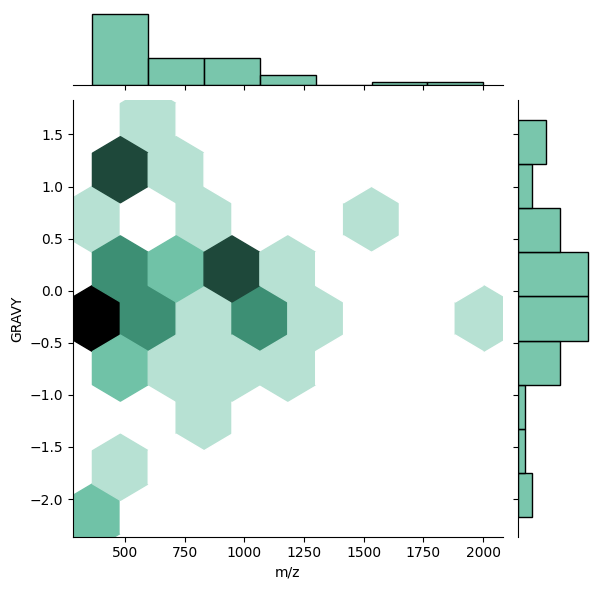

In [27]:

x = peptides_df['m/z']
y = peptides_df['GRAVY']


plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")


plt.show()

<Figure size 500x400 with 0 Axes>

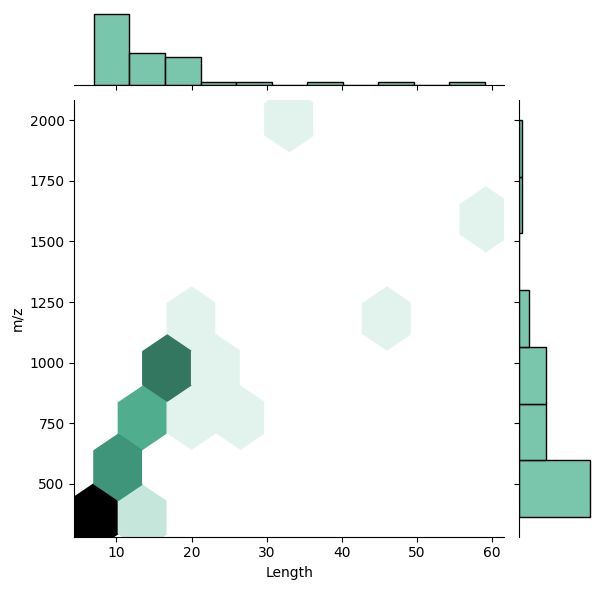

In [28]:
x = peptides_df['Length']
y = peptides_df['m/z']

plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

plt.show()

In [29]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)



gene
PDK1     12
UBE3B    30
dtype: int64


# Testing Area for Adding New Enzyme (i.e CL3 Q-S/A/G)

In [30]:
import re

def test_cleavage(sequence):
    """
    Simulate cleavage of a protein sequence using custom enzyme rule.
    
    Parameters:
    - sequence (str): The protein sequence to be cleaved.
    
    Returns:
    - list[str]: A list of peptides resulting from the cleavage.
    """
    # q_sag cleavage rule: Cleave at Q when followed by S, A, or G
    test_rule = '(L|Q)(?=S|A|G)'
    
    # Find all cleavage sites
    cleavage_sites = [match.end() for match in re.finditer(test_rule, sequence)]
    
    # Simulate cleavage to generate peptides
    peptides = []
    start = 0
    for site in cleavage_sites:
        peptide = sequence[start:site]
        if peptide:
            peptides.append(peptide)
        start = site
    # Add the last peptide fragment, if any
    if start < len(sequence):
        peptides.append(sequence[start:])
    
    return peptides

# Example protein sequences
sequences = [
    "KTILDDWQLSKKKAAA",
    "MQQSQQSAG",
]

# Test the q_sag cleavage rule on each sequence
for seq in sequences:
    peptides = test_cleavage(seq)
    print(f"Original sequence: {seq}")
    print(f"Peptides after test cleavage: {peptides}\n")


Original sequence: KTILDDWQLSKKKAAA
Peptides after test cleavage: ['KTILDDWQL', 'SKKKAAA']

Original sequence: MQQSQQSAG
Peptides after test cleavage: ['MQQ', 'SQQ', 'SAG']



# Peptide Analysis for CL3 Enzyme

In [31]:
silico.rules['CL3'] = '(L|Q)(?=S|A|G)'

In [32]:
peptide_properties_df = silico.generate_samples(proteome_df, target="Peptide", identifier="Gene", enzyme="CL3")


Processing your order with CL3-cut proteins.


KeyboardInterrupt: 

In [ ]:
peptides_df = pd.DataFrame(peptide_properties_df)
peptides_df = peptides_df.sort_values(by='z', ascending=True)
filtered_df = peptides_df[peptides_df['Length'] <= 40]
filtered_df['charge'] = filtered_df['z'].round(0)
filtered_df

In [ ]:
peptide_counts = peptides_df.groupby('gene').size()
print(peptide_counts)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
x = peptides_df['m/z']
y = peptides_df['GRAVY']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

In [ ]:
x = peptides_df['Length']
y = peptides_df['m/z']

# Plot the joint distribution using hexagonal bins
plt.figure(figsize=(5, 4))
sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# Show the plot
plt.show()

# Papain

In [ ]:
# silico.rules['papain'] = '[KR](?=[LG])'

In [ ]:
# peptide_properties_df = silico.generate_samples(proteome_df, target="Peptide", identifier="Gene", enzyme="papain")


In [ ]:
# peptides_df = pd.DataFrame(peptide_properties_df)
# peptides_df

In [ ]:
# x = peptides_df['Length']
# y = peptides_df['m/z']

# # Plot the joint distribution using hexagonal bins
# plt.figure(figsize=(5, 4))
# sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# # Show the plot
# plt.show()

In [ ]:
# x = peptides_df['Length']
# y = peptides_df['m/z']

# # Plot the joint distribution using hexagonal bins
# plt.figure(figsize=(5, 4))
# sns.jointplot(x=x, y=y, kind="hex", color="#4CB391")

# # Show the plot
# plt.show()

# Compare Two Enzymes

In [ ]:
enzyme1="trypsin"
e1_label="Trypsin"
enzyme2="glutamyl endopeptidase"
e2_label="GluC"
enzymes=[enzyme1,enzyme2]
enzyme_color={e1_label:"green",e2_label:"purple"}
two_proteome= proteome_df[proteome_df['Gene'].isin(['CDK1',"UBE3B"])] # Mute line below if you wish to focus on list of Genes
# two_proteome=proteome_df
two_digest={}
for enzyme in enzymes:
    temp_list = silico.generate_samples(two_proteome, target="Peptide", identifier="Gene", enzyme=enzyme)
    temp_df = pd.DataFrame(temp_list)
    temp_df["enzyme"] = enzyme
    two_digest[enzyme]=temp_df
combined_df = pd.concat(two_digest.values(), ignore_index=True)
combined_df['enzyme'] = combined_df['enzyme'].replace(enzyme1, e1_label)
combined_df['enzyme'] = combined_df['enzyme'].replace(enzyme2, e2_label)
combined_df

In [64]:
# Assuming 'enzyme' is the column indicating the enzyme used,
# and 'Gene' indicates the identified protein for each peptide
peptide_counts = combined_df.groupby('enzyme').size()
protein_counts = combined_df.groupby('enzyme')['gene'].nunique()

In [ ]:
peptide_counts

In [ ]:
protein_counts

In [67]:

# Create a DataFrame from the two Series for easier plotting
counts_df = pd.DataFrame({'Peptides': peptide_counts, 'Proteins': protein_counts}).reset_index()
colors = [enzyme_color[enzyme] for enzyme in counts_df['enzyme']]



In [68]:
peptide_data = counts_df[['enzyme', 'Peptides']]
protein_data = counts_df[['enzyme', 'Proteins']]

In [ ]:
# Create subplots with 1 row and 2 columns
fig, (ax_peptides, ax_proteins) = plt.subplots(1, 2, figsize=(8, 6))

# Bar plot for peptides on the first subplot
peptide_bars = ax_peptides.bar(peptide_data['enzyme'], peptide_data['Peptides'], color=[enzyme_color[e] for e in peptide_data['enzyme']], edgecolor='black')
ax_peptides.set_ylabel('Number of Peptides', fontsize=16)
ax_peptides.set_xticklabels(peptide_data['enzyme'], fontsize=16)
ax_peptides.tick_params(axis='y', labelsize=16)

# Adding labels on top of peptide bars
for bar in peptide_bars:
    height = bar.get_height()
    ax_peptides.annotate('{}'.format(int(height)),
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 1),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=16)

# Bar plot for proteins on the second subplot
protein_bars = ax_proteins.bar(protein_data['enzyme'], protein_data['Proteins'], color=[enzyme_color[e] for e in protein_data['enzyme']], edgecolor='black')
ax_proteins.set_ylabel('Number of Proteins', fontsize=16)
ax_proteins.set_xticklabels(protein_data['enzyme'], fontsize=16)
ax_proteins.tick_params(axis='y', labelsize=16)

# Adding labels on top of protein bars
for bar in protein_bars:
    height = bar.get_height()
    ax_proteins.annotate('{}'.format(int(height)),
                         xy=(bar.get_x() + bar.get_width() / 2, height),
                         xytext=(0, 1),  # 3 points vertical offset
                         textcoords="offset points",
                         ha='center', va='bottom', fontsize=16)

# Show plot
plt.tight_layout()
plt.show()





In [ ]:
# Filtering data for each enzyme
trypsin_data = combined_df[combined_df['enzyme'] == e1_label]
cl3_data = combined_df[combined_df['enzyme'] == e2_label]

# Plotting the KDE for the "m/z" feature for both enzymes
plt.figure(figsize=(2, 6))
sns.kdeplot(trypsin_data['z'], label=e1_label, color='green',common_norm=True)
sns.kdeplot(cl3_data['z'], label=e2_label, color='purple',common_norm=True)

# Setting the labels and legend
plt.xlabel('z', fontsize=16)
plt.ylabel('Density', fontsize=12)
plt.legend(fontsize=14)

# Control the range of x and y axis to limit whitespace if needed
plt.xlim(combined_df['z'].min(), combined_df['z'].max())
plt.ylim(0, None)  # For y-axis, setting the lower limit to 0 and upper limit to auto

# Display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Combine the two enzyme data into a single DataFrame for boxplot
trypsin_data['Enzyme'] = e1_label
cl3_data['Enzyme'] = e2_label
boxplot_data = pd.concat([trypsin_data[['z', 'Enzyme']], cl3_data[['z', 'Enzyme']]])

# Plotting the box plot for the "z" feature for both enzymes
plt.figure(figsize=(3, 6))
sns.violinplot(x='Enzyme', y='z', data=boxplot_data, palette=enzyme_color)

# Setting the labels and title
plt.ylabel('Peptide Charge (z)', fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# Display the plot
plt.tight_layout()
plt.show()


In [ ]:
x="Mass"
y="m/z"
g = sns.jointplot(
    data=combined_df,
    x=x,
    y=y,
    kind="kde",
    hue='enzyme',
    palette=enzyme_color,
    fill=False,
    bw_adjust=.12,
    marginal_kws=dict(common_norm=False, fill=True)
)

# Set font size for various elements
g.set_axis_labels(x, y, fontsize=14)  # Set axis label font size
g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size
# Control the range of x and y axis
g.ax_joint.set_xlim(0, 12000) 
g.ax_joint.set_ylim(0, 4000)  
# Show the plot
plt.show()


In [ ]:
x="Length"
y="GRAVY"
g = sns.jointplot(
    data=combined_df,
    x=x,
    y=y,
    kind="kde",
    hue='enzyme',
    palette=enzyme_color,
    fill=False,
    bw_adjust=.12,
    marginal_kws=dict(common_norm=False, fill=True)
)

# Set font size for various elements
g.set_axis_labels(x, y, fontsize=14)  # Set axis label font size
g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size
# Control the range of x and y axis
g.ax_joint.set_xlim(0, 125)  
g.ax_joint.set_ylim(-4, 4) 
# Show the plot
plt.show()

In [74]:
combined_df.to_excel("Pierre_GluC_PDK1_UBE3B.xlsx")


In [ ]:
# x="m/z"
# y="GRAVY"
# g = sns.jointplot(
#     data=peptides_df,
#     x="m/z",
#     y="GRAVY",
#     kind="kde",
# )

# # Set font size for various elements
# g.set_axis_labels("m/z", "Length", fontsize=14)  # Set axis label font size
# g.ax_joint.tick_params(axis='both', which='major', labelsize=14)  # Set tick label font size

# # Show the plot
# plt.show()


### Use this to compare two enzymes, need to merge df first. 

In [ ]:
proteome_df

In [76]:
# Example of mapping step if needed:
protein_sequence_map = proteome_df.set_index('Gene')['Peptide'].to_dict()  # Adjust column names as necessary
combined_df['Protein_Sequence'] = combined_df['gene'].map(protein_sequence_map)


In [ ]:
combined_df.columns

In [78]:
def Pep2Pro(protein, peptides):
    protein = re.sub(r'[^A-Z]', '', protein)
    mask = np.zeros(len(protein), dtype=np.int8)
    for peptide in peptides:
        indices = [m.start() for m in re.finditer('(?={})'.format(re.sub(r'[^A-Z]', '', peptide)), protein)]
        for i in indices:
            mask[i:i + len(peptide)] = 1
    return mask.sum() / mask.size


In [ ]:
# Filter data for each enzyme
df_trypsin = combined_df[combined_df['enzyme'] == e1_label]
df_CL3 = combined_df[combined_df['enzyme'] == e2_label]

# Define a function to calculate coverage for each group
def calculate_coverage(group):
    protein_sequence = group['Protein_Sequence'].iloc[0]
    peptides = group['peptide'].tolist()
    return Pep2Pro(protein_sequence, peptides)

# Group by 'gene' and calculate coverage
coverage_trypsin = df_trypsin.groupby('gene').apply(calculate_coverage)
coverage_CL3 = df_CL3.groupby('gene').apply(calculate_coverage)


In [ ]:
print(df_trypsin.head())
print("Number of rows in df_trypsin:", len(df_trypsin))


In [81]:
# Correct conversion of coverage Series to DataFrames and renaming the coverage column
coverage_trypsin_df = coverage_trypsin.reset_index().rename(columns={0: e1_label})
coverage_CL3_df = coverage_CL3.reset_index().rename(columns={0: e2_label})

# Merge the coverage data
coverage_merged = pd.merge(coverage_trypsin_df, coverage_CL3_df, on='gene', how='outer').fillna(0)
coverage_merged[e1_label] = coverage_merged[e1_label] * 100
coverage_merged[e2_label] = coverage_merged[e2_label] * 100



In [ ]:
coverage_merged.rename(columns={'gene': 'Gene'}, inplace=True)
coverage_merged

In [ ]:

coverage_long = pd.melt(coverage_merged, id_vars=['Gene'], value_vars=[e1_label, e2_label], var_name='Enzyme', value_name='Coverage')
palette = {e1_label: 'green', e2_label: 'purple'}
plt.figure(figsize=(10, 6))
sns.violinplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, fill=None,inner='quart')
plt.ylabel('Coverage (%)',fontsize=16)
plt.xlabel('Enzyme',fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

# Show the plot
plt.show()


In [ ]:

palette = {e1_label: 'green', e2_label: 'purple'}

plt.figure(figsize=(8, 6))
sns.boxplot(x='Enzyme', y='Coverage', data=coverage_long, palette=palette, width=0.5)

plt.ylabel('Coverage (%)', fontsize=16)
plt.xlabel('Enzyme', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.show()


In [ ]:
coverage_long = pd.melt(coverage_merged, id_vars=['Gene'], value_vars=[e1_label, e2_label], var_name='Enzyme', value_name='Coverage')
palette = {e1_label: 'green', e2_label: 'purple'}

plt.figure(figsize=(7, 6))

# Plot KDE for Trypsin
sns.kdeplot(data=coverage_long[coverage_long['Enzyme'] == e1_label]['Coverage'], 
            color=palette[e1_label], label=e1_label, fill=True, alpha=0.5)

# Plot KDE for CL3
sns.kdeplot(data=coverage_long[coverage_long['Enzyme'] == e2_label]['Coverage'], 
            color=palette[e2_label], label=e2_label, fill=True, alpha=0.5)

plt.ylabel('Density', fontsize=16)
plt.xlabel('Coverage (%)', fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=14,loc="upper left")

# Show the plot
plt.show()

In [ ]:
# Example adjustment: Simplify to handle a single cleavage per peptide
def capture_flanking_sequences(protein_sequence, peptide_sequence, flank_length):
    peptide_start = protein_sequence.find(peptide_sequence)
    if peptide_start == -1:
        return {'n_cut': 'Not found', 'c_cut': 'Not found'}
    
    # Example rule: cleavage occurs at the start of the peptide
    n_cut_start = max(0, peptide_start - flank_length)
    c_cut_end = min(len(protein_sequence), peptide_start + len(peptide_sequence) + flank_length)
    
    n_cut = protein_sequence[n_cut_start:peptide_start]
    c_cut = protein_sequence[peptide_start + len(peptide_sequence):c_cut_end]
    
    return {'n_cut': n_cut, 'c_cut': c_cut}



# Apply the adjusted function to each row in df_trypsin
df_trypsin['flanking_sequences'] = df_trypsin.apply(
    lambda row: capture_flanking_sequences(row['Protein_Sequence'], row['peptide'], 5), axis=1
)

# Apply the adjusted function to each row in df_trypsin
df_CL3['flanking_sequences'] = df_CL3.apply(
    lambda row: capture_flanking_sequences(row['Protein_Sequence'], row['peptide'], 5), axis=1
)



In [ ]:
print(df_trypsin[['peptide', 'flanking_sequences']].head())


In [ ]:
import pandas as pd

# Define positions relative to the cleavage site
positions = ['P5', 'P4', 'P3', 'P2', 'P1', 'P1\'', 'P2\'', 'P3\'', 'P4\'', 'P5\'']

# Initialize a DataFrame to hold the counts for each amino acid at each position
tryp_aa_counts = pd.DataFrame(columns=['AminoAcid'] + positions).set_index('AminoAcid')
cl3_aa_counts = pd.DataFrame(columns=['AminoAcid'] + positions).set_index('AminoAcid')
# Populate the DataFrame with zeros for each amino acid at each position
amino_acids = 'ACDEFGHIKLMNPQRSTVWYUX'  # Standard amino acids
for aa in amino_acids:
    tryp_aa_counts.loc[aa] = [0] * len(positions)
    cl3_aa_counts.loc[aa] = [0] * len(positions)
cl3_aa_counts


In [ ]:
def update_aa_counts_from_flanking(row, aa_counts):
    # Extract the flanking sequences
    n_cut = row['flanking_sequences']['n_cut']
    c_cut = row['flanking_sequences']['c_cut']

    # Update counts for N-terminal side
    for i, aa in enumerate(n_cut[::-1], 1):
        if i <= len(positions) // 2:  # Assuming positions are symmetric around cleavage
            aa_counts.loc[aa, f'P{i}'] += 1

    # Update counts for C-terminal side
    for i, aa in enumerate(c_cut, 1):
        if i <= len(positions) // 2:  # Assuming positions are symmetric around cleavage
            aa_counts.loc[aa, f"P{i}'"] += 1

# Apply the function to each row in the DataFrame
df_trypsin.apply(lambda row: update_aa_counts_from_flanking(row, tryp_aa_counts), axis=1)
df_CL3.apply(lambda row: update_aa_counts_from_flanking(row, cl3_aa_counts), axis=1)



# from multiprocessing import Pool


# def process_chunk(chunk):
#     # Initialize a local count DataFrame for this chunk
#     local_counts = pd.DataFrame(columns=positions, index=list('ACDEFGHIKLMNPQRSTVWYUX')).fillna(0)
    
#     for _, row in chunk.iterrows():
#         n_cut = row['flanking_sequences']['n_cut']
#         c_cut = row['flanking_sequences']['c_cut']
        
#         # Update counts for N-terminal side
#         for i, aa in enumerate(n_cut[::-1], 1):
#             if i <= len(positions) // 2:
#                 local_counts.loc[aa, f'P{i}'] += 1
        
#         # Update counts for C-terminal side
#         for i, aa in enumerate(c_cut, 1):
#             if i <= len(positions) // 2:
#                 local_counts.loc[aa, f"P{i}'"] += 1
    
#     return local_counts

# def parallelize_dataframe_processing(df, func, num_partitions, num_cores):
#     df_split = np.array_split(df, num_partitions)
#     pool = Pool(num_cores)
#     result_list = pool.map(func, df_split)
#     pool.close()
#     pool.join()
#     # Combine the results from all chunks
#     combined_result = pd.concat(result_list, axis=0).groupby(level=0).sum()
#     return combined_result

# # Example of how to use this setup
# num_partitions = 10  # Adjust based on your dataset size and available memory
# num_cores = 4  # Adjust based on your machine's capabilities

# # Replace df_trypsin with the actual DataFrame you're working with
# tryp_aa_counts = parallelize_dataframe_processing(df_trypsin, process_chunk, num_partitions, num_cores)
# cl3_aa_counts = parallelize_dataframe_processing(df_CL3, process_chunk, num_partitions, num_cores)

# # tryp_aa_counts and cl3_aa_counts now hold the aggregated amino acid counts for each position



In [ ]:
t_aa_probabilities = tryp_aa_counts.div(tryp_aa_counts.sum(axis=0), axis=1)
t_aa_probabilities.head(23)
t_aa_df=t_aa_probabilities.T
t_aa_df.reset_index(drop=True, inplace=True)
t_aa_df.columns.name = None
t_aa_df.index.name = 'pos'
t_aa_df


In [ ]:
c_aa_probabilities = cl3_aa_counts.div(cl3_aa_counts.sum(axis=0), axis=1)
c_aa_probabilities.head(23)
c_aa_df=c_aa_probabilities.T
c_aa_df.reset_index(drop=True, inplace=True)
c_aa_df.columns.name = None
c_aa_df.index.name = 'pos'
c_aa_df

In [ ]:
logomaker.list_font_names()

In [ ]:
# TRYPSIN LOGO
ss_logo = logomaker.Logo(t_aa_df,
                         width=.9,
                         vpad=.2,
                         stack_order='small_on_top',
                         color_scheme='hydrophobicity',
                         font_name="Ebrima",
                         fade_probabilities=False,
                          center_values=False,
                         alpha=1,figsize=[6,2])
# style using Logo methods
ss_logo.style_spines(spines=['left', 'right'], visible=True)
# ss_logo.fade_glyphs_in_probability_logo(v_alpha0=0.6,v_alpha1=1)
# style using Axes methods
ss_logo.ax.set_xticks(range(len(t_aa_df)))
ss_logo.ax.set_xticklabels('%+d'%x for x in [ -5, -4, -3, -2, -1, 1, 2, 3, 4,5])
ss_logo.ax.set_yticks([0, .5, 1])
ss_logo.ax.axvline(4.5, color='k', linewidth=2, linestyle=':')
ss_logo.ax.set_ylabel('probability',fontsize=12)



In [ ]:
# CL3 LOGO
ss_logo = logomaker.Logo(c_aa_df,
                         width=.9,
                         vpad=.2,
                         stack_order='small_on_top',
                         color_scheme='hydrophobicity',
                         font_name="Ebrima",
                         fade_probabilities=False,
                          center_values=False,
                         alpha=1,figsize=[6,2])
# style using Logo methods
ss_logo.style_spines(spines=['left', 'right'], visible=True)
# ss_logo.fade_glyphs_in_probability_logo(v_alpha0=0.6,v_alpha1=1)
# style using Axes methods
ss_logo.ax.set_xticks(range(len(c_aa_df)))
ss_logo.ax.set_xticklabels('%+d'%x for x in [ -5, -4, -3, -2, -1, 1, 2, 3, 4,5])
ss_logo.ax.set_yticks([0, .5, 1])
ss_logo.ax.axvline(4.5, color='k', linewidth=2, linestyle=':')
ss_logo.ax.set_ylabel('probability',fontsize=12)
